In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data_phones = pd.read_csv("data_phones.csv")
data_phones.sample(3)

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,prices
203,B01FCFZS3G,Samsung,Samsung Galaxy S7 Edge G935A 32GB AT&T - Black...,https://www.amazon.com/Samsung-Galaxy-Edge-G93...,https://m.media-amazon.com/images/I/61y-TkZ5lW...,3.5,https://www.amazon.com/product-reviews/B01FCFZS3G,204,NaN
82,B00K0NS0P4,Motorola,Motorola Moto G (1st Generation) Unlocked Cell...,https://www.amazon.com/Motorola-Moto-Generatio...,https://m.media-amazon.com/images/I/71L5LzVmrc...,4.0,https://www.amazon.com/product-reviews/B00K0NS0P4,1,$209.65
601,B07HFHX6HX,Samsung,Samsung Galaxy Note 8 N950U 64GB Unlocked GSM ...,https://www.amazon.com/Samsung-Galaxy-Note-Sma...,https://m.media-amazon.com/images/I/61OOxwvUan...,4.2,https://www.amazon.com/product-reviews/B07HFHX6HX,334,$314.99


### Splitting the price column into 2 columns

Here, I separated the column by the dollar sign and then removed the dollar sign from both columns and removed the comma as the thousand separator.

In [ ]:
data_phones[['actual_price', 'installment_price']] = data_phones['prices'].str.split(",(?=\$)", expand=True)

In [ ]:
data_phones['actual_price'] = data_phones['actual_price'].str.replace('$', '')
data_phones['actual_price'] = data_phones['actual_price'].str.replace(',', '')
data_phones['actual_price'] = data_phones['actual_price'].astype(float)

<ipython-input-82-6a5f2ea8d1b7>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  data_phones['actual_price'] = data_phones['actual_price'].str.replace('$', '')


In [ ]:
data_phones['installment_price'] = data_phones['installment_price'].str.replace('$', '')
data_phones['installment_price'] = data_phones['installment_price'].str.replace(',', '')
data_phones['installment_price'] = data_phones['installment_price'].astype(float)

<ipython-input-83-d30eeada4d53>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  data_phones['installment_price'] = data_phones['installment_price'].str.replace('$', '')


In [ ]:
data_phones.tail()

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,prices,actual_price,installment_price
787,B07WFJ6HRF,Apple,"Apple iPhone XS, 512GB, Gold - For Verizon (Re...",https://www.amazon.com/Apple-iPhone-XS-512GB-G...,https://m.media-amazon.com/images/I/71kt40Gjzt...,3.7,https://www.amazon.com/product-reviews/B07WFJ6HRF,50,"$999.95,$1,349.99",999.95,1349.99
788,B07WKSVF6X,Samsung,"Samsung Galaxy A50 128GB, 4GB RAM 6.4"" Display...",https://www.amazon.com/Samsung-A50-Display-Fac...,https://m.media-amazon.com/images/I/61HyCNLJ2+...,4.7,https://www.amazon.com/product-reviews/B07WKSVF6X,7,$304.99,304.99,NaN
789,B07WVRJQ7V,Samsung,"Samsung Galaxy S9 (64GB, 4GB RAM) 5.8"" QHD+ Di...",https://www.amazon.com/Samsung-Galaxy-S9-Displ...,https://m.media-amazon.com/images/I/71EpwFTgLO...,2.0,https://www.amazon.com/product-reviews/B07WVRJQ7V,1,$519.99,519.99,NaN
790,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",https://www.amazon.com/Motorola-Vision-Display...,https://m.media-amazon.com/images/I/51xgfG4A28...,3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,5,$139.99,139.99,NaN
791,B07X51T2VK,HUAWEI,"Honor 5X Unlocked Smartphone, 16GB Dark Grey (...",https://www.amazon.com/Honor-Unlocked-Smartpho...,https://m.media-amazon.com/images/I/71qG253Lcx...,4.0,https://www.amazon.com/product-reviews/B07X51T2VK,1,$74.99,74.99,NaN


In [ ]:
data_phones= data_phones.dropna(subset =['actual_price'])

In [ ]:
data_phones['installment_price']= data_phones['installment_price'].fillna(0)

<ipython-input-86-5f3a22416d72>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_phones['installment_price']= data_phones['installment_price'].fillna(0)


In [ ]:
data_phones.head(5)

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,prices,actual_price,installment_price
1,B0009N5L7K,Motorola,Motorola I265 phone,https://www.amazon.com/Motorola-i265-I265-phon...,https://m.media-amazon.com/images/I/419WBAVDAR...,2.9,https://www.amazon.com/product-reviews/B0009N5L7K,7,$49.95,49.95,0.0
6,B001DZY4KI,Sony,Sony Ericsson G700 Triband GSM Phone Bronze (U...,https://www.amazon.com/Sony-Ericsson-Triband-B...,https://m.media-amazon.com/images/I/51mL10Inzc...,2.0,https://www.amazon.com/product-reviews/B001DZY4KI,1,$78.99,78.99,0.0
8,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,https://www.amazon.com/New-Nokia-1100-for-Trac...,https://m.media-amazon.com/images/I/91IUe3nDP7...,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,8,$99.99,99.99,0.0
9,B00280QJFU,Samsung,Samsung T301G Prepaid Phone (Tracfone),https://www.amazon.com/Samsung-T301G-Prepaid-P...,https://m.media-amazon.com/images/I/71QX+Kiri4...,3.5,https://www.amazon.com/product-reviews/B00280QJFU,133,$59.89,59.89,0.0
10,B0029X7UHC,Motorola,Motorola I205 cell phone nextel/Boost,https://www.amazon.com/Motorola-I205-phone-nex...,https://m.media-amazon.com/images/I/81RGb1X2dp...,2.9,https://www.amazon.com/product-reviews/B0029X7UHC,2,$99.95,99.95,0.0


In [ ]:
data_phones.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 577 entries, 1 to 791
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   asin               577 non-null    object 
 1   brand              577 non-null    object 
 2   title              577 non-null    object 
 3   url                577 non-null    object 
 4   image              577 non-null    object 
 5   rating             577 non-null    float64
 6   reviewUrl          577 non-null    object 
 7   totalReviews       577 non-null    int64  
 8   prices             577 non-null    object 
 9   actual_price       577 non-null    float64
 10  installment_price  577 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 54.1+ KB


### Web scraping the reviews using the review URL

I scrapped the website and extracted the reviews and the ratings using the review url

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Initialize Sentiment Intensity Analyzer
sid = SentimentIntensityAnalyzer()

In [ ]:
# Perform Sentiment Analysis on Reviews
#sentiment_scores = []
#for review in reviews:
#    sentiment = sid.polarity_scores(review)
#    sentiment_scores.append(sentiment)


In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
# Function to extract reviews from a given URL
def extract_reviews(url):
    headers= {
      "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
      "Accept-Encoding": "gzip, deflate, br",
      "Accept-Language": "en-US,en;q=0.9",
      "Sec-Ch-Ua": "\"Google Chrome\";v=\"119\", \"Chromium\";v=\"119\", \"Not?A_Brand\";v=\"24\"",
      "Sec-Ch-Ua-Mobile": "?0",
      "Sec-Ch-Ua-Platform": "\"macOS\"",
      "Sec-Fetch-Dest": "document",
      "Sec-Fetch-Mode": "navigate",
      "Sec-Fetch-Site": "cross-site",
      "Sec-Fetch-User": "?1",
      "Upgrade-Insecure-Requests": "1",
      "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
      "X-Amzn-Trace-Id": "Root=1-656fa176-1142588a38de53eb1c009ee9"
    }
    try:
        response = requests.get(url,headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')
        review_elements = soup.find_all(class_='review-text')
        reviews = [review.get_text() for review in review_elements]
        return reviews
    except Exception as e:
        print(f"Error retrieving reviews from {url}: {e}")
        return []

In [ ]:
def extract_reviews_ratings(url):
    headers= {
      "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
      "Accept-Encoding": "gzip, deflate, br",
      "Accept-Language": "en-US,en;q=0.9",
      "Sec-Ch-Ua": "\"Google Chrome\";v=\"119\", \"Chromium\";v=\"119\", \"Not?A_Brand\";v=\"24\"",
      "Sec-Ch-Ua-Mobile": "?0",
      "Sec-Ch-Ua-Platform": "\"macOS\"",
      "Sec-Fetch-Dest": "document",
      "Sec-Fetch-Mode": "navigate",
      "Sec-Fetch-Site": "cross-site",
      "Sec-Fetch-User": "?1",
      "Upgrade-Insecure-Requests": "1",
      "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
      "X-Amzn-Trace-Id": "Root=1-656fa176-1142588a38de53eb1c009ee9"
    }
    try:
        response = requests.get(url,headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')
        review_elements = soup.find_all(class_='review-rating')
        reviews = [review.get_text() for review in review_elements]
        return reviews
    except Exception as e:
        print(f"Error retrieving reviews from {url}: {e}")
        return []

In [ ]:
data_phones_new = data_phones
data_phones_new

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,prices,actual_price,installment_price
1,B0009N5L7K,Motorola,Motorola I265 phone,https://www.amazon.com/Motorola-i265-I265-phon...,https://m.media-amazon.com/images/I/419WBAVDAR...,2.9,https://www.amazon.com/product-reviews/B0009N5L7K,7,$49.95,49.95,0.00
6,B001DZY4KI,Sony,Sony Ericsson G700 Triband GSM Phone Bronze (U...,https://www.amazon.com/Sony-Ericsson-Triband-B...,https://m.media-amazon.com/images/I/51mL10Inzc...,2.0,https://www.amazon.com/product-reviews/B001DZY4KI,1,$78.99,78.99,0.00
8,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,https://www.amazon.com/New-Nokia-1100-for-Trac...,https://m.media-amazon.com/images/I/91IUe3nDP7...,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,8,$99.99,99.99,0.00
9,B00280QJFU,Samsung,Samsung T301G Prepaid Phone (Tracfone),https://www.amazon.com/Samsung-T301G-Prepaid-P...,https://m.media-amazon.com/images/I/71QX+Kiri4...,3.5,https://www.amazon.com/product-reviews/B00280QJFU,133,$59.89,59.89,0.00
10,B0029X7UHC,Motorola,Motorola I205 cell phone nextel/Boost,https://www.amazon.com/Motorola-I205-phone-nex...,https://m.media-amazon.com/images/I/81RGb1X2dp...,2.9,https://www.amazon.com/product-reviews/B0029X7UHC,2,$99.95,99.95,0.00
...,...,...,...,...,...,...,...,...,...,...,...
787,B07WFJ6HRF,Apple,"Apple iPhone XS, 512GB, Gold - For Verizon (Re...",https://www.amazon.com/Apple-iPhone-XS-512GB-G...,https://m.media-amazon.com/images/I/71kt40Gjzt...,3.7,https://www.amazon.com/product-reviews/B07WFJ6HRF,50,"$999.95,$1,349.99",999.95,1349.99
788,B07WKSVF6X,Samsung,"Samsung Galaxy A50 128GB, 4GB RAM 6.4"" Display...",https://www.amazon.com/Samsung-A50-Display-Fac...,https://m.media-amazon.com/images/I/61HyCNLJ2+...,4.7,https://www.amazon.com/product-reviews/B07WKSVF6X,7,$304.99,304.99,0.00
789,B07WVRJQ7V,Samsung,"Samsung Galaxy S9 (64GB, 4GB RAM) 5.8"" QHD+ Di...",https://www.amazon.com/Samsung-Galaxy-S9-Displ...,https://m.media-amazon.com/images/I/71EpwFTgLO...,2.0,https://www.amazon.com/product-reviews/B07WVRJQ7V,1,$519.99,519.99,0.00
790,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",https://www.amazon.com/Motorola-Vision-Display...,https://m.media-amazon.com/images/I/51xgfG4A28...,3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,5,$139.99,139.99,0.00


In [ ]:
# Extract reviews and ratings from URLs in data_phones DataFrame and create a DataFrame
data = []
for index, row in data_phones.iterrows():
    reviews = extract_reviews(row['reviewUrl'])
    ratings = extract_reviews_ratings(row['reviewUrl'])
    # Assuming reviews and ratings are lists of strings
    for review, rating in zip(reviews, ratings):
        data.append({
            'asin': row['asin'],
            'brand': row['brand'],
            'title': row['title'],
            'rating': row['rating'],
            'reviewUrl': row['reviewUrl'],
            'review': review,
            'rating_text': rating
        })

In [ ]:
# Create a DataFrame from the extracted data
data_df = pd.DataFrame(data)

In [ ]:
data_df

,asin,brand,title,rating,reviewUrl,review,rating_text
0,B008P2SUEI,Samsung,Samsung Entro Mobile Phone Black | Virgin Mobile,3.6,https://www.amazon.com/product-reviews/B008P2SUEI,\nIt was a giant pain to activate. I had two ...,5.0 out of 5 stars
1,B008P2SUEI,Samsung,Samsung Entro Mobile Phone Black | Virgin Mobile,3.6,https://www.amazon.com/product-reviews/B008P2SUEI,\nI had previously purchased two other phones....,1.0 out of 5 stars
2,B008P2SUEI,Samsung,Samsung Entro Mobile Phone Black | Virgin Mobile,3.6,https://www.amazon.com/product-reviews/B008P2SUEI,\nI received my Samsung Entro today and I love...,4.0 out of 5 stars
3,B008P2SUEI,Samsung,Samsung Entro Mobile Phone Black | Virgin Mobile,3.6,https://www.amazon.com/product-reviews/B008P2SUEI,\nI bought this phone for my grandma when we s...,3.0 out of 5 stars
4,B008P2SUEI,Samsung,Samsung Entro Mobile Phone Black | Virgin Mobile,3.6,https://www.amazon.com/product-reviews/B008P2SUEI,\nIt's Not a camera and a tiny internet machin...,5.0 out of 5 stars
...,...,...,...,...,...,...,...
477,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,\npersonal use. the unit acts like it is locke...,5.0 out of 5 stars
478,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,"\nIt is not compatible with Altice Mobile. So,...",5.0 out of 5 stars
479,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,\nExcellent phone for the price and he has a g...,3.0 out of 5 stars
480,B07X51T2VK,HUAWEI,"Honor 5X Unlocked Smartphone, 16GB Dark Grey (...",4.0,https://www.amazon.com/product-reviews/B07X51T2VK,"\nWhat a great phone! Sleek, fast, great sound...",4.0 out of 5 stars


In [ ]:
import re

In [ ]:
data_df['numeric_rating'] = data_df['rating_text'].apply(lambda x: float(re.search(r'\d+\.\d+', x).group()) if re.search(r'\d+\.\d+', x) else None)
data_df.head()

,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating
0,B01J8C50TQ,Samsung,Samsung Galaxy Sol 4G LTE Unlocked 8GB Memory ...,3.4,https://www.amazon.com/product-reviews/B01J8C50TQ,\nSmall internal memory but I installed an SD ...,5.0 out of 5 stars,5.0
1,B01J8C50TQ,Samsung,Samsung Galaxy Sol 4G LTE Unlocked 8GB Memory ...,3.4,https://www.amazon.com/product-reviews/B01J8C50TQ,\nSo far so good. Working perfect.\n,1.0 out of 5 stars,1.0
2,B01J8C50TQ,Samsung,Samsung Galaxy Sol 4G LTE Unlocked 8GB Memory ...,3.4,https://www.amazon.com/product-reviews/B01J8C50TQ,"\nIt doesn't have radio, that's not cool...!!!\n",4.0 out of 5 stars,4.0
3,B01J8C50TQ,Samsung,Samsung Galaxy Sol 4G LTE Unlocked 8GB Memory ...,3.4,https://www.amazon.com/product-reviews/B01J8C50TQ,"\nUpdating my initial review, below. Sure wish...",4.0 out of 5 stars,4.0
4,B01J8C50TQ,Samsung,Samsung Galaxy Sol 4G LTE Unlocked 8GB Memory ...,3.4,https://www.amazon.com/product-reviews/B01J8C50TQ,\nI love everything about the phone\n,4.0 out of 5 stars,4.0


In [ ]:
#data_df.to_csv('reviews_full_data.csv')

In [ ]:
reviews_data = pd.read_csv('reviews_full_data (1).csv')

In [ ]:
reviews_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3131 entries, 0 to 3130
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      3131 non-null   int64  
 1   asin            3131 non-null   object 
 2   brand           3131 non-null   object 
 3   title           3131 non-null   object 
 4   rating          3131 non-null   float64
 5   reviewUrl       3131 non-null   object 
 6   review          3129 non-null   object 
 7   rating_text     3131 non-null   object 
 8   numeric_rating  3131 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 220.3+ KB


In [ ]:
# remove na from the df
reviews_data = reviews_data.dropna(subset =['review'])

## Extracting sentiment from the reviews using NLP
### Basic NLTK

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [ ]:
# Apply the sentiment analysis function to each row in the 'review' column
sentiment_scores = reviews_data['review'].apply(lambda x: sia.polarity_scores(x))

# Create new columns for each sentiment score
reviews_data['neg'] = sentiment_scores.apply(lambda x: x['neg'])
reviews_data['neu'] = sentiment_scores.apply(lambda x: x['neu'])
reviews_data['pos'] = sentiment_scores.apply(lambda x: x['pos'])
reviews_data['compound'] = sentiment_scores.apply(lambda x: x['compound'])

# Display the updated DataFrame
reviews_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3129 entries, 0 to 3130
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      3129 non-null   int64  
 1   asin            3129 non-null   object 
 2   brand           3129 non-null   object 
 3   title           3129 non-null   object 
 4   rating          3129 non-null   float64
 5   reviewUrl       3129 non-null   object 
 6   review          3129 non-null   object 
 7   rating_text     3129 non-null   object 
 8   numeric_rating  3129 non-null   float64
 9   neg             3129 non-null   float64
 10  neu             3129 non-null   float64
 11  pos             3129 non-null   float64
 12  compound        3129 non-null   float64
dtypes: float64(6), int64(1), object(6)
memory usage: 342.2+ KB


### Comparing Ratings by Score

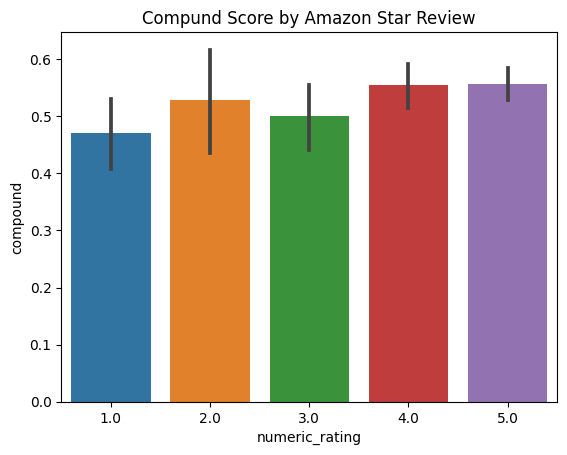

In [ ]:
ax = sns.barplot(data=reviews_data, x='numeric_rating', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

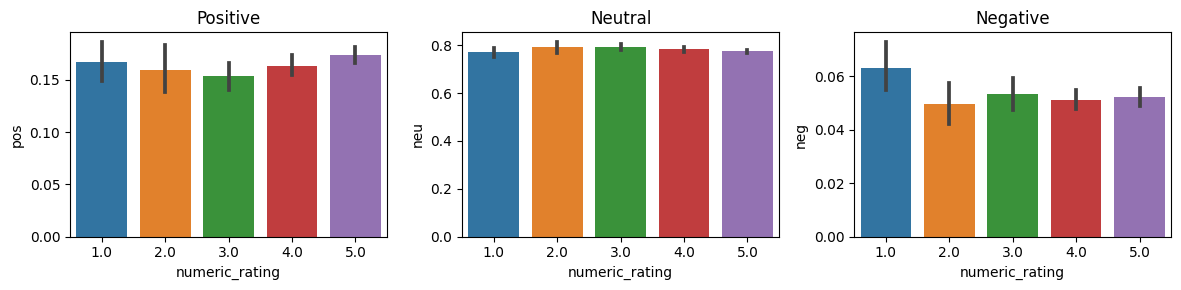

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=reviews_data, x='numeric_rating', y='pos', ax=axs[0])
sns.barplot(data=reviews_data, x='numeric_rating', y='neu', ax=axs[1])
sns.barplot(data=reviews_data, x='numeric_rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

Basically, i still need to work on it but the reviews don't seem to have any influence on the ratings

### Roberta model

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [ ]:
# Define a function to apply the model to each review and return the scores dictionary
def apply_roberta_scores(review):
    encoded_text = tokenizer(review, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded_text)
    scores = output.logits[0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }
    return scores_dict

In [ ]:
# Apply the function to each row in the 'review' column and add the scores to the DataFrame
roberta_scores = reviews_data['review'].apply(apply_roberta_scores)

In [ ]:
roberta_scores_df = pd.DataFrame(roberta_scores.tolist())

In [ ]:
reviews_data = pd.concat([reviews_data, roberta_scores_df], axis=1)
# Display the updated DataFrame
print(reviews_data)

      Unnamed: 0        asin     brand  \
0            0.0  B001DZY4KI      Sony   
1            1.0  B0027VKQPE     Nokia   
2            2.0  B0027VKQPE     Nokia   
3            3.0  B0027VKQPE     Nokia   
4            4.0  B0027VKQPE     Nokia   
...          ...         ...       ...   
3128      3128.0  B07WXKWDT2  Motorola   
3129      3129.0  B07X51T2VK    HUAWEI   
3130      3130.0  B07X51T2VK    HUAWEI   
203          NaN         NaN       NaN   
1014         NaN         NaN       NaN   

                                                  title  rating  \
0     Sony Ericsson G700 Triband GSM Phone Bronze (U...     2.0   
1                           Nokia New 1100 for Tracfone     3.2   
2                           Nokia New 1100 for Tracfone     3.2   
3                           Nokia New 1100 for Tracfone     3.2   
4                           Nokia New 1100 for Tracfone     3.2   
...                                                 ...     ...   
3128  Motorola Moto G7 Pla

In [ ]:
reviews_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3131 entries, 0 to 1014
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      3129 non-null   float64
 1   asin            3129 non-null   object 
 2   brand           3129 non-null   object 
 3   title           3129 non-null   object 
 4   rating          3129 non-null   float64
 5   reviewUrl       3129 non-null   object 
 6   review          3129 non-null   object 
 7   rating_text     3129 non-null   object 
 8   numeric_rating  3129 non-null   float64
 9   neg             3129 non-null   float64
 10  neu             3129 non-null   float64
 11  pos             3129 non-null   float64
 12  compound        3129 non-null   float64
 13  roberta_neg     3127 non-null   float32
 14  roberta_neu     3127 non-null   float32
 15  roberta_pos     3127 non-null   float32
 16  roberta_neg     3129 non-null   float32
 17  roberta_neu     3129 non-null   f

In [ ]:
reviews_data = reviews_data.dropna(subset=['numeric_rating'])
reviews_data['numeric_rating'] = pd.to_numeric(reviews_data['numeric_rating'], errors='coerce')

<ipython-input-153-dae55fadb0f7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_data['numeric_rating'] = pd.to_numeric(reviews_data['numeric_rating'], errors='coerce')


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=reviews_data, x='numeric_rating', y='roberta_pos', ax=axs[0])
sns.barplot(data=reviews_data, x='numeric_rating', y='roberta_neu', ax=axs[1])
sns.barplot(data=reviews_data, x='numeric_rating', y='roberta_neg', ax=axs[2])
axs[0].set_title('Roberta Positive')
axs[1].set_title('Roberta Neutral')
axs[2].set_title('Roberta Negative')
plt.tight_layout()
plt.show()

From the graphs, we see that the higher the rating, the higher the positive score and in the negative score reduces as the score gets higher.
I will now apply and see what sentiments look like for each brand.

In [ ]:
reviews_data.to_csv('sentiment_full_data.csv')

In [ ]:
reviews_data.head()

,Unnamed: 0,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos
0,0.0,B001DZY4KI,Sony,Sony Ericsson G700 Triband GSM Phone Bronze (U...,2.0,https://www.amazon.com/product-reviews/B001DZY4KI,\nThe phone itself just has software problems....,2.0 out of 5 stars,2.0,0.152,0.745,0.103,-0.5667,0.892834,0.087013,0.020153
1,1.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nI love this phone.Retro early 2000s kind of ...,5.0 out of 5 stars,5.0,0.026,0.815,0.159,0.8910,0.002834,0.017437,0.979729
2,2.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nThe best phone I have used say 10 years back...,1.0 out of 5 stars,1.0,0.000,0.794,0.206,0.7753,0.002076,0.021295,0.976629
3,3.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,"\nThe product turns on, but if you are looking...",5.0 out of 5 stars,5.0,0.000,1.000,0.000,0.0000,0.510828,0.410781,0.078392
4,4.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nI've had this phone for eons---at least 10 y...,5.0 out of 5 stars,5.0,0.009,0.911,0.081,0.9543,0.261068,0.390533,0.348399


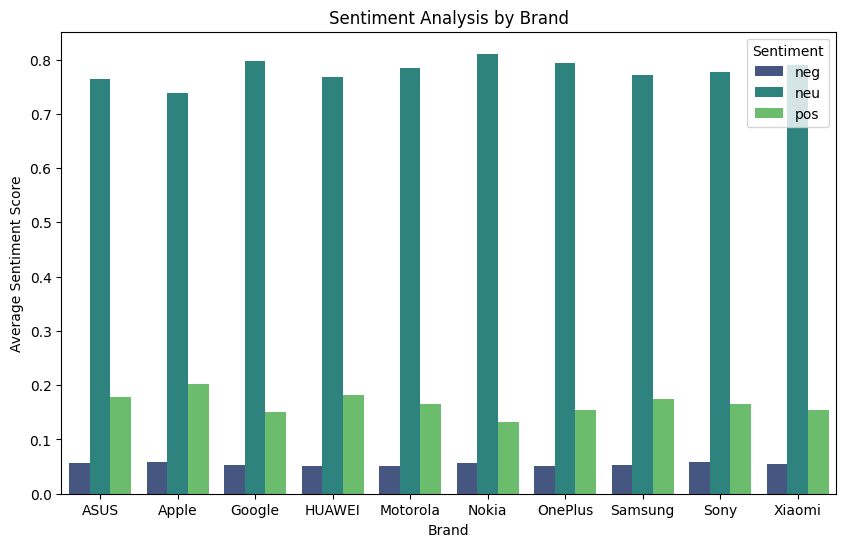

In [ ]:
# Group by brand and calculate the average sentiment scores
brand_sentiment = reviews_data.groupby('brand')[['neg', 'neu', 'pos']].mean().reset_index()

melted_df = pd.melt(brand_sentiment, id_vars='brand', var_name='Sentiment', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='brand', y='Score', hue='Sentiment', data=melted_df, palette='viridis')
plt.title('Sentiment Analysis by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Sentiment Score')
plt.show()


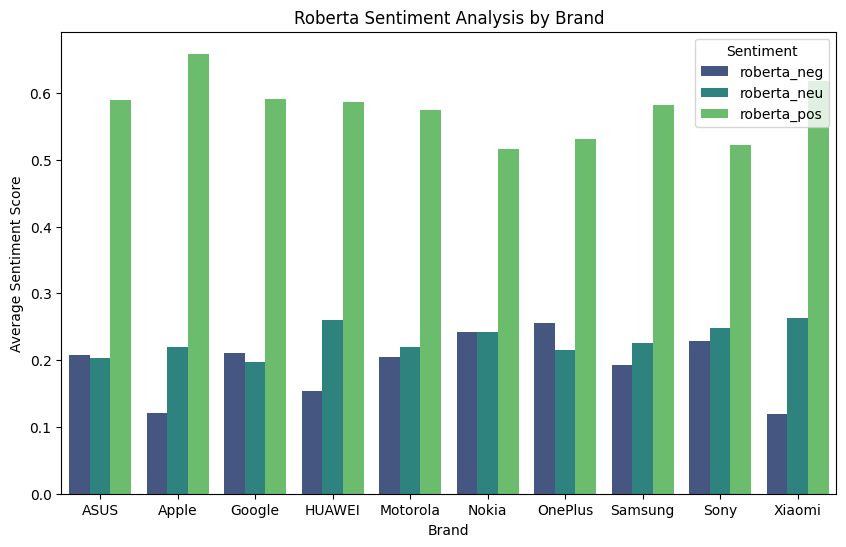

In [ ]:
# Group by brand and calculate the average sentiment scores
brand_roberta_sentiment = reviews_data.groupby('brand')[['roberta_neg', 'roberta_neu', 'roberta_pos']].mean().reset_index()

melted_df = pd.melt(brand_roberta_sentiment, id_vars='brand', var_name='Sentiment', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='brand', y='Score', hue='Sentiment', data=melted_df, palette='viridis')
plt.title('Roberta Sentiment Analysis by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Sentiment Score')
plt.show()

In [ ]:
# compare negative reviews with ratings


# Plan for Analysis


### 1.Overall Sentiment Analysis:

Calculate the overall sentiment for each review using a weighted average of the sentiment scores (neg, neu, pos).
Visualize the distribution of sentiment scores across all reviews.

### 2. Rating vs. Sentiment:

Explore the relationship between the given ratings and the sentiment scores.
Check if there's a correlation between the numerical rating and the compound sentiment score.

### 3. Brand Comparison:

Compare the average sentiment scores between different brands.
Visualize brand-wise sentiment scores to identify trends or differences.

### 4. Word Frequency Analysis:

Conduct a word frequency analysis to identify the most common words in reviews.
Explore if certain words are associated with positive or negative sentiment.

### 5. Topic Modeling:

Use topic modeling techniques (such as LDA) to identify topics present in the reviews.
Explore if there are common themes or subjects discussed in the reviews.

### 6. Word Clouds:

Create word clouds to visually represent the most frequent words in positive and negative reviews.

### 7. Customer Feedback Trends:

Identify common customer feedback or complaints.
Analyze trends in customer feedback to guide product improvements.